<a href="https://colab.research.google.com/github/adenikeadewumi/adenikeadewumi/blob/main/Working_with_trained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Working with YOLO model



In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model_yolo= YOLO("/content/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model_yolo.predict(
    source="//content/rotated_by_15_Screen Shot 2018-06-12 at 8.59.51 PM.png",
    conf=0.25,   # confidence threshold
    save=True    # saves output image
)



image 1/1 //content/rotated_by_15_Screen Shot 2018-06-12 at 8.59.51 PM.png: 640x640 2 rotten bananas, 235.4ms
Speed: 6.9ms preprocess, 235.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [ ]:
for r in results:
    boxes = r.boxes
    for box in boxes:
        cls = int(box.cls[0])          # class index
        conf = float(box.conf[0])      # confidence
        xyxy = box.xyxy[0].tolist()    # bounding box

        print(cls, conf, xyxy)


3 0.6457478404045105 [71.45552062988281, 7.64668083190918, 216.18109130859375, 353.399169921875]
3 0.32052430510520935 [70.69464111328125, 2.8257246017456055, 299.4144287109375, 356.1087951660156]


#Note


##labels 0 and 2 are apples

##labels 1 and 3 are bananas

Homography

In [ ]:
import cv2
import numpy as np
import math
from ultralytics import YOLO


# HOMOGRAPHY CLASS

class HomographyMapper:
    def __init__(self, H_map):
        #self.image_points = np.array(image_points, dtype=np.float32)
        #self.world_points = np.array(world_points, dtype=np.float32)
        #self.H = H_mapself.compute_homography()
        self.H = np.array(H_map, dtype=np.float32)
        if self.H.shape != (3, 3):
           raise ValueError(f"Homography matrix must be 3x3, got {self.H.shape}")

    #def compute_homography(self):
        #H, _ = cv2.findHomography(self.image_points, self.world_points)
        #return H

    def pixel_to_world(self, x, y):
        pixel_point = np.array([[[x, y]]], dtype=np.float32)
        world_point = cv2.perspectiveTransform(pixel_point, self.H)
        X, Y = world_point[0][0]
        return float(X), float(Y)




In [ ]:
def process_fruit_detections(results, mapper):
    """
    results: YOLO prediction results
    mapper: HomographyMapper object
    """
    picks = []

    for r in results:
        # --- NMS / TOP-1 SELECTION START ---
        # Check if any boxes were detected
        if len(r.boxes) == 0:
            continue

        # We pick the index of the box with the highest confidence score
        # This ensures we only 'clean' the output to one single target per frame
        best_box_idx = r.boxes.conf.argmax()
        box = r.boxes[best_box_idx]
        # --- NMS / TOP-1 SELECTION END ---

        # Extract data from the 'best' box only
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_idx = int(box.cls[0])
        label = r.names[cls_idx] # Updated to use r.names for better portability
        conf = float(box.conf[0])

        # Center of bounding box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        # Map to world coordinates
        Xw, Yw = mapper.pixel_to_world(cx, cy)
        Z_pick = 5

        # Determine angle for bananas
        if "banana" in label.lower():
            dx = x2 - x1
            dy = y2 - y1
            # Note: math.atan2(dy, dx) calculates the diagonal angle of the box
            angle_rad = math.atan2(dy, dx)
            angle_deg = math.degrees(angle_rad)
        else:
            angle_deg = 0

        picks.append({
            "label": label,
            "confidence": conf,
            "X_world": Xw,
            "Y_world": Yw,
            "Z_pick": Z_pick,
            "angle_deg": angle_deg
        })

    return picks

In [ ]:
#main script that maps pixel points to world point

h_map = np.array([[2.54848853e-02, -4.28079447e-02, -3.49809201e+00],
                   [-1.84254238e-03, -2.87196279e-02, 2.86170864e+00],
                   [-2.20445845e-04, -2.70760600e-03, 1.00000000e+00]])


mapper= HomographyMapper(h_map)
# Run YOLO prediction on an image
#This  part will be editted to make predictions on image feeds
online_img = cv2.imread('//content/rotated_by_15_Screen Shot 2018-06-12 at 8.59.51 PM.png')
resized = cv2.resize(online_img, (640, 640))
cv2.imwrite('/content/fresh_banana_resized.jpg', resized)

# Test on resized version
results = model_yolo.predict('/content/fresh_banana_resized.jpg', conf=0.25)


# Process detections to get pick points
pick_commands = process_fruit_detections(results, mapper)

#Print results
for cmd in pick_commands:
    print(f"Fruit: {cmd['label']}, Conf: {cmd['confidence']:.2f}, "
          f"World: ({cmd['X_world']:.2f}, {cmd['Y_world']:.2f}), "
          f"Z_pick: {cmd['Z_pick']}, Angle: {cmd['angle_deg']:.2f}°")


image 1/1 /content/fresh_banana_resized.jpg: 640x640 2 rotten bananas, 226.4ms
Speed: 3.4ms preprocess, 226.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Fruit: rotten banana, Conf: 0.59, World: (-158.95, -102.11), Z_pick: 5, Angle: 67.19°


In [ ]:
#main script that maps pixel points to world point

h_map = np.array([[2.54848853e-02, -4.28079447e-02, -3.49809201e+00],
                   [-1.84254238e-03, -2.87196279e-02, 2.86170864e+00],
                   [-2.20445845e-04, -2.70760600e-03, 1.00000000e+00]])

mapper= HomographyMapper(h_map)
# Run YOLO prediction on an image
#This  part will be editted to make predictions on image feeds
online_img = cv2.imread('/content/rottenBanana-509-_jpg.rf.338cb620c5ba7f27f957fb952fdb5760.jpg')
resized = cv2.resize(online_img, (640, 640))
cv2.imwrite('/content/fresh_banana_resized.jpg', resized)

# Test on resized version
results = model_yolo.predict('/content/fresh_banana_resized.jpg', conf=0.25)


# Process detections to get pick points
pick_commands = process_fruit_detections(results, mapper)

#Print results
for cmd in pick_commands:
    print(f"Fruit: {cmd['label']}, Conf: {cmd['confidence']:.2f}, "
          f"World: ({cmd['X_world']:.2f}, {cmd['Y_world']:.2f}), "
          f"Z_pick: {cmd['Z_pick']}, Angle: {cmd['angle_deg']:.2f}°")


image 1/1 /content/fresh_banana_resized.jpg: 640x640 1 rotten banana, 159.1ms
Speed: 2.8ms preprocess, 159.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Fruit: rotten banana, Conf: 0.90, World: (67.77, 53.31), Z_pick: 5, Angle: 29.67°


#Working with ONNX model




In [ ]:
%pip install onnxruntime opencv-python numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 104.4 MB/s eta 0:00:00


In [ ]:

onnx_path= model.export(
    format="onnx",
    imgsz=320,
    simplify=True,
    opset=12
)
print(f"Model exported to: {onnx_path}")

Ultralytics 8.4.13 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/best (2).pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 8, 2100) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 183ms
Prepared 4 packages in 7.18s
Installed 4 packages in 270ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.1
 + onnxslim==0.1.84

requirements: AutoUpdate success ✅ 8.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.84...
ONNX: export success ✅ 9.4s, saved as '/content/best (2).onnx' (11.6 MB)

Ex

In [ ]:
import cv2
import numpy as np
import onnxruntime as ort

class ONNXFruitDetector:
    def __init__(self, onnx_model_path, class_names):
        """
        Initialize ONNX model for fruit detection

        Args:
            onnx_model_path: Path to .onnx model file
            class_names: Dict of class names {0: 'fresh apple', 1: 'rotten apple', ...}
        """
        # Load ONNX model
        self.session = ort.InferenceSession(onnx_model_path)

        # Get model input details
        self.input_name = self.session.get_inputs()[0].name
        self.input_shape = self.session.get_inputs()[0].shape
        self.input_height = self.input_shape[2]
        self.input_width = self.input_shape[3]

        # Get output names
        self.output_names = [output.name for output in self.session.get_outputs()]

        self.class_names = class_names

        print(f"Model loaded: {onnx_model_path}")
        print(f"Input shape: {self.input_shape}")
        print(f"Input name: {self.input_name}")
        print(f"Output names: {self.output_names}")

    def preprocess(self, image):
        """
        Preprocess image for ONNX model

        Args:
            image: BGR image from cv2.imread()

        Returns:
            Preprocessed image ready for inference
        """
        # Resize to model input size (letterbox)
        img = cv2.resize(image, (self.input_width, self.input_height))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Transpose from HWC to CHW (Height, Width, Channels -> Channels, Height, Width)
        img = img.transpose(2, 0, 1)

        # Add batch dimension
        img = np.expand_dims(img, axis=0)

        return img

    def postprocess(self, outputs, conf_threshold=0.25, iou_threshold=0.45):
        """
        Post-process ONNX model outputs

        Args:
            outputs: Raw model outputs
            conf_threshold: Confidence threshold
            iou_threshold: IoU threshold for NMS

        Returns:
            List of detections [x1, y1, x2, y2, confidence, class_id]
        """
        # YOLOv8 output format: [batch, 84, 8400] or similar
        # First 4 values are bbox coords, rest are class scores
        predictions = outputs[0][0]  # Remove batch dimension

        # Transpose to [8400, 84]
        predictions = predictions.transpose()

        detections = []

        for prediction in predictions:
            # Extract bbox and scores
            x_center, y_center, width, height = prediction[:4]
            class_scores = prediction[4:]

            # Get class with highest score
            class_id = np.argmax(class_scores)
            confidence = class_scores[class_id]

            # Filter by confidence
            if confidence >= conf_threshold:
                # Convert from center format to corner format
                x1 = x_center - width / 2
                y1 = y_center - height / 2
                x2 = x_center + width / 2
                y2 = y_center + height / 2

                detections.append([x1, y1, x2, y2, confidence, class_id])

        # Apply Non-Maximum Suppression (NMS)
        if len(detections) > 0:
            detections = np.array(detections)
            detections = self.nms(detections, iou_threshold)

        return detections

    def nms(self, detections, iou_threshold):
        """
        Apply Non-Maximum Suppression
        """
        if len(detections) == 0:
            return []

        # Extract coordinates and scores
        boxes = detections[:, :4]
        scores = detections[:, 4]

        # Use OpenCV's NMS
        indices = cv2.dnn.NMSBoxes(
            boxes.tolist(),
            scores.tolist(),
            score_threshold=0.0,
            nms_threshold=iou_threshold
        )

        if len(indices) > 0:
            return detections[indices.flatten()]
        return []

    def predict(self, image_path, conf_threshold=0.25):
        """
        Run inference on an image

        Args:
            image_path: Path to image file
            conf_threshold: Confidence threshold

        Returns:
            detections: List of detections
            original_image: Original image for visualization
        """
        # Load image
        original_image = cv2.imread(image_path)
        img_height, img_width = original_image.shape[:2]

        # Preprocess
        input_tensor = self.preprocess(original_image)

        # Run inference
        outputs = self.session.run(self.output_names, {self.input_name: input_tensor})

        # Post-process
        detections = self.postprocess(outputs, conf_threshold)

        # Scale boxes back to original image size
        if len(detections) > 0:
            scale_x = img_width / self.input_width
            scale_y = img_height / self.input_height

            detections[:, [0, 2]] *= scale_x  # x coordinates
            detections[:, [1, 3]] *= scale_y  # y coordinates

        return detections, original_image

    def draw_detections(self, image, detections):
        """
        Draw bounding boxes on image
        """
        img_annotated = image.copy()

        for detection in detections:
            x1, y1, x2, y2, conf, class_id = detection

            # Draw box
            cv2.rectangle(img_annotated,
                         (int(x1), int(y1)),
                         (int(x2), int(y2)),
                         (0, 255, 0), 2)

            # Draw label
            label = f"{self.class_names[int(class_id)]}: {conf:.2f}"
            cv2.putText(img_annotated, label,
                       (int(x1), int(y1) - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        return img_annotated

Model loaded: /content/best (2).onnx
Input shape: [1, 3, 320, 320]
Input name: images
Output names: ['output0']
Found 2 detections
Fruit: fresh banana, Conf: 0.86, World: (3793.58, 2253.35)
Fruit: fresh banana, Conf: 0.49, World: (26.10, 23.13)


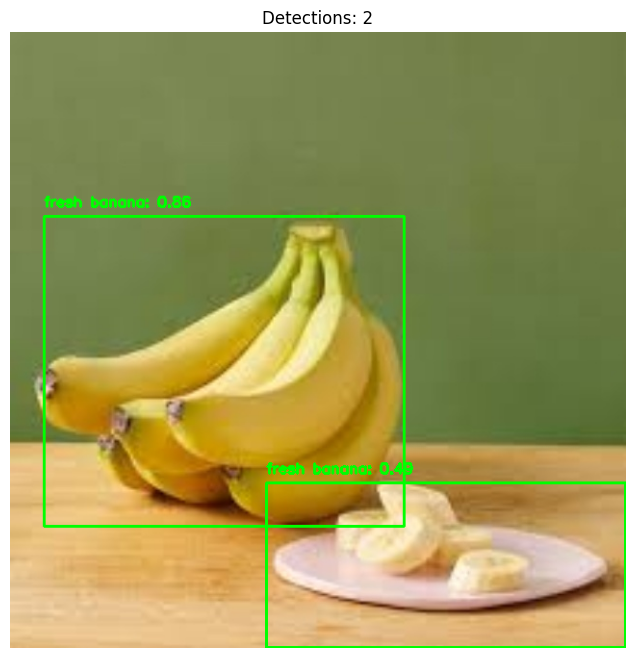

In [ ]:
# Initialize ONNX detector
class_names = {
    0: 'fresh apple',
    1: 'fresh banana',
    2: 'rotten apple',
    3: 'rotten banana'
}

detector = ONNXFruitDetector('/content/best (2).onnx', class_names)

# Initialize homography mapper
h_map = np.array([[2.54848853e-02, -4.28079447e-02, -3.49809201e+00],
                   [-1.84254238e-03, -2.87196279e-02, 2.86170864e+00],
                   [-2.20445845e-04, -2.70760600e-03, 1.00000000e+00]])

mapper = HomographyMapper(h_map)

# Process image
image_path = '/content/fresh_banana_resized.jpg'
detections, original_image = detector.predict(image_path, conf_threshold=0.25)

print(f"Found {len(detections)} detections")

# Process each detection
pick_commands = []

for detection in detections:
    x1, y1, x2, y2, conf, class_id = detection

    # Calculate center of bounding box
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2

    # Convert to world coordinates
    world_x, world_y = mapper.pixel_to_world(x_center, y_center)

    pick_command = {
        'fruit': class_names[int(class_id)],
        'confidence': float(conf),
        'pixel_coords': (x_center, y_center),
        'world_coords': (world_x, world_y),
        'bbox': (x1, y1, x2, y2)
    }

    pick_commands.append(pick_command)

    print(f"Fruit: {pick_command['fruit']}, "
          f"Conf: {pick_command['confidence']:.2f}, "
          f"World: ({world_x:.2f}, {world_y:.2f})")

# Visualize
annotated = detector.draw_detections(original_image, detections)
cv2.imwrite('/content/annotated_output.jpg', annotated)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f'Detections: {len(detections)}')
plt.axis('off')
plt.show()

Integrate this later in order to use the best runtime on raspberr pi for the predictions

In [ ]:
import onnxruntime as ort

print(f"Providers available: {ort.get_available_providers()}")
session = ort.InferenceSession('/content/best (2).onnx')
print(f"Using provider: {session.get_providers()}")

Providers available: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Using provider: ['CPUExecutionProvider']


#Working with NCNN

In [ ]:
from ultralytics import YOLO

# 1. Load your custom trained model (the .pt file)
model = YOLO("/content/best (2).pt")

# 2. Export the model to NCNN format
# int8=True is optional: it makes the model even faster but slightly less accurate
# imgsz should match the resolution you used during training (usually 640)
model.export(format="ncnn", imgsz=640, int8=False)

print("Conversion complete! Look for a folder named 'best_ncnn_model'.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/best (2).pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (6.0 MB)

NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260112...
NCNN: export success ✅ 3.2s, saved as '/content/best (2)_ncnn_model' (11.6 MB)

Export complete (3.6s)
Results saved to /content
Predict:         yolo predict task=detect model=/content/best (2)_ncnn_model imgsz=640 
Validate:        yolo val task=detect model=/content/best (2)_ncnn_model imgsz=640 data=/content/fruit_dataset-2/data.yaml  
Visualize:       https://netron.app
Conversion complete! Look for a folder named 'best_ncnn_model'.


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Setup Model and Homography
# Point to your newly created NCNN folder
model = YOLO("/content/best (2)_ncnn_model", task="detect")

h_map = np.array([[2.54848853e-02, -4.28079447e-02, -3.49809201e+00],
                  [-1.84254238e-03, -2.87196279e-02, 2.86170864e+00],
                  [-2.20445845e-04, -2.70760600e-03, 1.00000000e+00]])

mapper = HomographyMapper(h_map)

def process_fruit_detections(results, mapper):
    commands = []
    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Get pixel coordinates (x1, y1, x2, y2)
            b = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            label = model.names[cls]

            # Calculate the center of the fruit (u, v)
            u_center = (b[0] + b[2]) / 2
            v_center = (b[1] + b[3]) / 2

            # Map pixel (u, v) to World (X, Y) using your Homography Mapper
            world_coords = mapper.map_point(u_center, v_center)

            # Logic for sorting based on class
            # You can customize Z_pick or angles based on fruit type
            z_height = -5.0 if label == "rotten" else -10.0

            commands.append({
                'label': label,
                'confidence': conf,
                'X_world': world_coords[0],
                'Y_world': world_coords[1],
                'Z_pick': z_height,
                'angle_deg': 0.0 # Placeholder for rotation logic
            })
    return commands

# 2. Main Execution Loop (Optimized for Video/Feed)
# If using a live camera: cap = cv2.VideoCapture(0)
online_img = cv2.imread('/content/fresh_banana_resized.jpg')

if online_img is not None:
    # Resize in-memory only (don't write to disk!)
    img_resized = cv2.resize(online_img, (640, 640))

    # Run NCNN prediction (verbose=False keeps the console clean)
    results = model.predict(img_resized, conf=0.25, verbose=False)

    # Process detections to get physical pick points
    pick_commands = process_fruit_detections(results, mapper)

    # 3. Output for the Robotic Arm
    for cmd in pick_commands:
        print(f"Target Found! [{cmd['label']}] Conf: {cmd['confidence']:.2f}")
        print(f" -> Move Arm to: X={cmd['X_world']:.2f}, Y={cmd['Y_world']:.2f}, Z={cmd['Z_pick']}")
        print("---")

Inverse Kinematics

Working with undistorted frames


In [ ]:
import numpy as np
import cv2

# Load the saved calibration results
data = np.load('calibration_data.npz')
K = data['camera_matrix']
D = data['dist_coefficients']

#Modularization

In [ ]:
%%writefile main.py
import cv2
from motor import DynamixelController
from model import RobotVision

def main():
    arm = DynamixelController(device_name='/dev/ttyUSB0')
    brain = RobotVision('best.pt')
    cap = cv2.VideoCapture(0)
    arm.init_arm()

    # Target Bin Locations (World Coordinates in CM)
    BINS = {"fresh_banana": (25, 15, 10), "rotten_banana": (-25, 15, 10)}

    try:
        while True:
            ret, frame = cap.read()
            if not ret: continue

            target = brain.get_pick_point(frame)
            if target:
                print(f"Action: Picking {target['label']}")

                # 1. HOVER ABOVE
                hover = brain.calculate_ik(target['x'], target['y'], 15, target['angle'])
                arm.sync_move(hover)

                # 2. PICK
                pick = brain.calculate_ik(target['x'], target['y'], 5, target['angle'])
                arm.sync_move(pick)
                arm.sync_move({6: 580}) # Close

                # 3. LIFT
                arm.sync_move(hover)

                # 4. SORT
                bx, by, bz = BINS.get(target['label'], (0, 20, 10))
                bin_pos = brain.calculate_ik(bx, by, bz, 0)
                arm.sync_move(bin_pos)
                arm.sync_move({6: 300}) # Open

                # RETURN HOME
                arm.sync_move({1: 512, 2: 512, 3: 512, 7: 512})

            cv2.imshow("Robot Cam", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
    finally:
        arm.close()
        cap.release()

if __name__ == "__main__":
    main()

Overwriting main.py


In [ ]:
%%writefile model.py
import numpy as np
import cv2
import math
from ultralytics import YOLO

class RobotVision:
    def __init__(self, model_path='best.pt'):
        self.model = YOLO(model_path)
        # Your specific H-MAP from Colab
        self.H = np.array([[2.54848853e-02, -4.28079447e-02, -3.49809201e+00],
                          [-1.84254238e-03, -2.87196279e-02, 2.86170864e+00],
                          [-2.20445845e-04, -2.70760600e-03, 1.00000000e+00]], dtype=np.float32)
        # Arm lengths (Update these after measurement!)
        self.L1 = 15.0
        self.L2 = 15.0

    def get_pick_point(self, frame):
        results = self.model.predict(frame, conf=0.4, verbose=False)
        for r in results:
            if len(r.boxes) == 0: continue
            best_idx = r.boxes.conf.argmax()
            box = r.boxes[best_idx]
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            label = r.names[int(box.cls[0])]

            # 1. PIXEL TO WORLD
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            pixel_point = np.array([[[cx, cy]]], dtype=np.float32)
            world_point = cv2.perspectiveTransform(pixel_point, self.H)
            xw, yw = world_point[0][0]

            # 2. BANANA ANGLE
            angle = math.degrees(math.atan2(y2-y1, x2-x1)) if "banana" in label.lower() else 0
            return {"label": label, "x": xw, "y": yw, "angle": angle}
        return None

    def calculate_ik(self, x, y, z, angle):
        # Base Rotation (Servo 1)
        theta_base = math.degrees(math.atan2(y, x))
        s1_unit = 512 + int(theta_base * 3.41)

        # Reach Geometry (Law of Cosines)
        r = math.sqrt(x**2 + y**2)
        h = z - 10 # Adjust '10' to your shoulder height
        dist = math.sqrt(r**2 + h**2)

        try:
            cos_q3 = (self.L1**2 + self.L2**2 - dist**2) / (2 * self.L1 * self.L2)
            q3 = math.degrees(math.acos(np.clip(cos_q3, -1, 1)))
            s3_unit = 512 - int(q3 * 3.41) # Elbow

            alpha = math.degrees(math.atan2(h, r))
            cos_q2 = (self.L1**2 + dist**2 - self.L2**2) / (2 * self.L1 * dist)
            q2 = math.degrees(math.acos(np.clip(cos_q2, -1, 1)))
            s2_unit = 512 + int((q2 + alpha) * 3.41) # Shoulder
        except:
            return {1: 512, 2: 512, 3: 512, 7: 512}

        # Wrist Orientation (Servo 7)
        s7_unit = 512 + int(angle * 3.41)

        return {1: s1_unit, 2: s2_unit, 3: s3_unit, 7: s7_unit}

Overwriting model.py


In [ ]:
%%writefil

In [ ]:
%%writefile __init__.py

Writing __init__.py
